In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import quspin
from matplotlib.ticker import NullFormatter
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

plt.style.use("science")
plt.rcParams.update({"font.size": 18, "lines.linewidth": 4, "lines.markersize": 8})
os.makedirs("plots", exist_ok=True)

def spin_operator(S, component):
    basis = quspin.basis.spin_basis_1d(L=1, S=str(int(S)) if S % 1 == 0 else f"{int(2*S)}/2")
    def matrix(op):
        return quspin.operators.hamiltonian([[op, [[1., 0]]]], [], basis=basis,
            dtype=np.complex128, check_symm=False, check_herm=False).toarray()
    return matrix("z") if component == "z" else (matrix("+") - matrix("-")) / (2j)

def load_states(S, tau, ell):
    suffix = f"order{ell}_Omega3.7000" if ell else "noCD"
    states = {}
    with h5py.File(f"data/S{S}_chi1_g1_tau{tau:.4f}_Nsteps1000_{suffix}.h5", "r") as saved:
        def collect(name, item):
            key = name.rsplit("/", 1)[-1]
            if isinstance(item, h5py.Dataset) and key.startswith("h_"):
                states[key] = item[()].reshape(-1)
        saved.visititems(collect)
    return states

def normalize(state):
    return state / np.sqrt(np.vdot(state, state).real)

def curve(xs, evaluate):
    points = []
    for x in xs:
        try:
            y = evaluate(x)
        except (OSError, KeyError):
            continue
        if np.isfinite(y) and y > 0:
            points.append((x, y))
    return np.asarray(points).T if points else (np.array([]), np.array([]))

def format_axis(ax, xlabel, ylabel, which="both"):
    ax.set_xlabel(xlabel, fontsize=26)
    ax.set_ylabel(ylabel, fontsize=24)
    ax.tick_params(axis="both", labelsize=17, pad=6)
    ax.grid(True, which=which, linestyle="--", alpha=0.3)

def guide(ax, x0, x1, exponent, label, y0, label_x, offset, ha="center", va="bottom"):
    ax.loglog([x0, x1], [y0, y0*(x1/x0)**exponent], "--", color="0.25", zorder=5)
    ax.annotate(label, (label_x, y0*(label_x/x0)**exponent), xytext=offset,
                textcoords="offset points", ha=ha, va=va, fontsize=18, color="0.2", zorder=7)


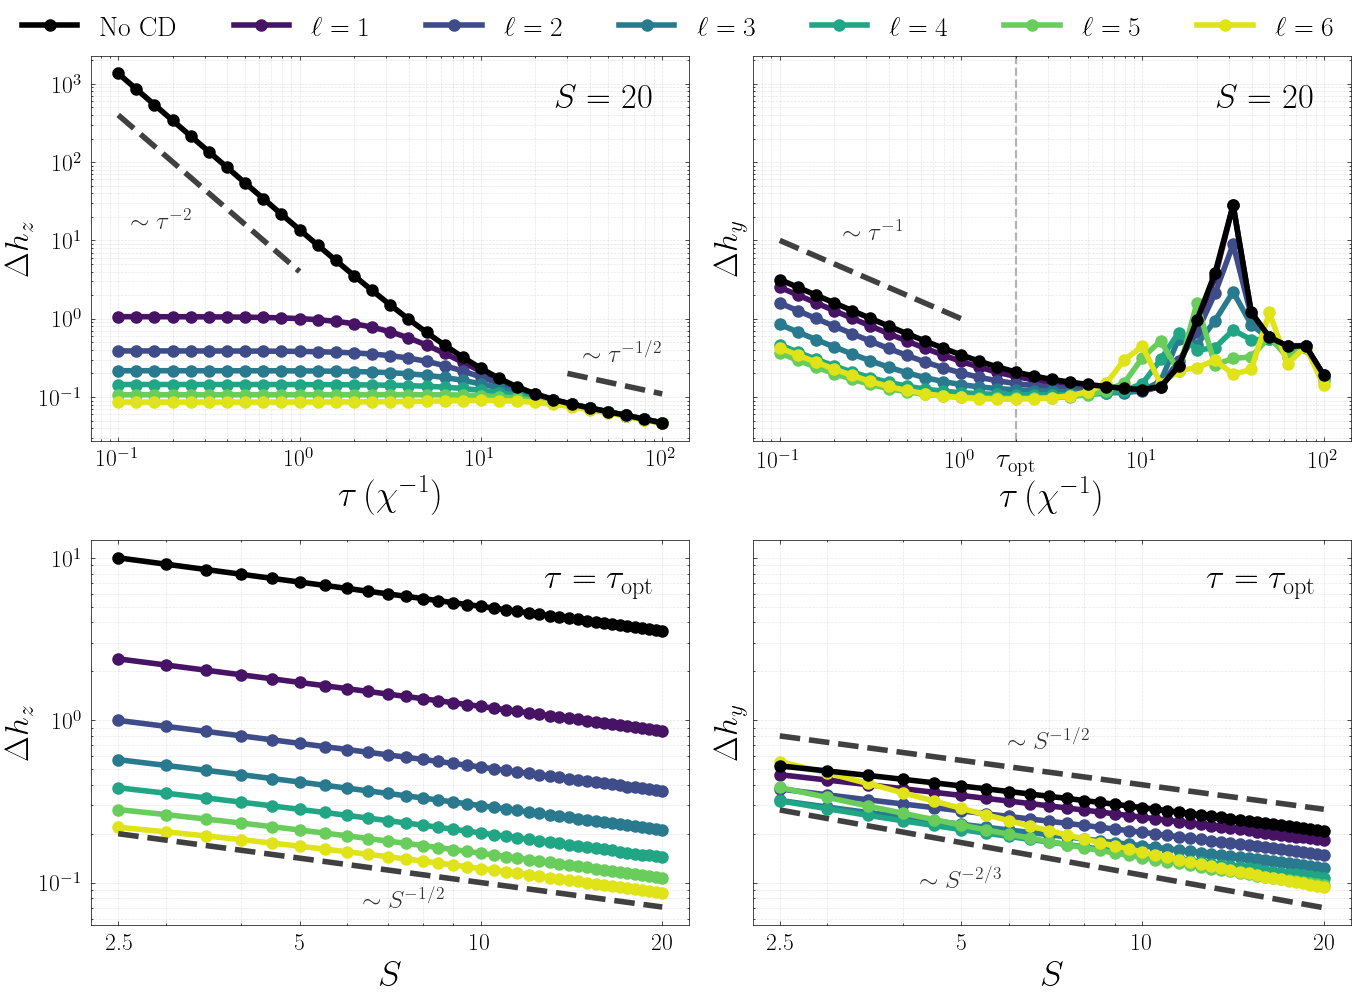

In [2]:
def delta_h(S, ell, component, tau):
    saved = load_states(S, tau, ell)
    states, fields = [], []
    for h in (0, -1e-3, 1e-3):
        distance, key = min((abs(float(k[2:]) - h), k) for k in saved)
        if distance > 1e-13:
            raise KeyError(h)
        states.append(normalize(saved[key]))
        fields.append(float(key[2:]))
    operator = spin_operator(S, component)
    mean, minus, plus = [np.vdot(state, operator @ state).real for state in states]
    variance = max(np.vdot(states[0], operator @ (operator @ states[0])).real - mean**2, 0)
    slope = (plus - minus) / (fields[2] - fields[1])
    return np.sqrt(variance) / abs(slope) if slope else np.nan

taus, spins = np.logspace(-1, 2, 31), np.arange(2.5, 20.01, 0.5)
valid_taus, values = curve(taus, lambda tau: delta_h(20.0, 6, "y", tau))
tau_opt = valid_taus[np.argmin(values)]
colors = [*plt.cm.viridis(np.linspace(0.05, 0.95, 6)), "black"]
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharey="row")
for row, xs in enumerate((taus, spins)):
    for ax, component in zip(axes[row], ("z", "y")):
        for ell, color in zip([*range(1, 7), 0], colors):
            x, y = curve(xs, lambda x: delta_h(20.0 if row == 0 else x, ell, component,
                                              x if row == 0 else tau_opt))
            ax.loglog(x, y, "o-", color=color, label=rf"$\ell={ell}$" if ell else r"$\mathrm{No\ CD}$")
        format_axis(ax, r"$\tau\,(\chi^{-1})$" if row == 0 else r"$S$", rf"$\Delta h_{{{component}}}$")
        ax.text(0.94, 0.93, r"$S=20$" if row == 0 else r"$\tau=\tau_{\mathrm{opt}}$",
                transform=ax.transAxes, ha="right", va="top", fontsize=25)

ax = axes[0, 1]
ax.axvline(tau_opt, color="0.35", linestyle="--", linewidth=1.6, alpha=0.45, zorder=1)
ax.set_xticks([0.1, 1, tau_opt, 10, 100], labels=[r"$10^{-1}$", r"$10^{0}$", "", r"$10^{1}$", r"$10^{2}$"])
ax.tick_params(axis="x", which="major", labelsize=17, pad=7)
ax.annotate(r"$\tau_{\mathrm{opt}}$", (tau_opt, 0), xycoords=ax.get_xaxis_transform(),
            xytext=(0, -7), textcoords="offset points", ha="center", va="top", fontsize=20, clip_on=False, zorder=10)
guide(axes[0, 0], 0.1, 1, -2, r"$\sim\tau^{-2}$", 400, 0.32, (-12, -12), "right", "top")
guide(axes[0, 0], 30, 100, -0.5, r"$\sim\tau^{-1/2}$", 0.2, 60, (0, 14))
guide(axes[0, 1], 0.1, 1, -1, r"$\sim\tau^{-1}$", 10, 0.2, (6, 14), "left")
guide(axes[1, 0], 2.5, 20, -0.5, r"$\sim S^{-1/2}$", 0.2, 9, (-6, -8), "right", "top")
guide(axes[1, 1], 2.5, 20, -0.5, r"$\sim S^{-1/2}$", 0.8, 7, (0, 14))
guide(axes[1, 1], 2.5, 20, -2/3, r"$\sim S^{-2/3}$", 0.28, 5, (0, -36))
for ax in axes[1]:
    ax.set_xticks([2.5, 5, 10, 20], labels=["2.5", "5", "10", "20"])
    ax.xaxis.set_minor_formatter(NullFormatter())
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[-1:] + handles[:-1], labels[-1:] + labels[:-1], loc="upper center",
           bbox_to_anchor=(0.5, 0.935), frameon=False, fontsize=20, ncols=7)
fig.tight_layout(rect=(0, 0, 1, 0.90), h_pad=1, w_pad=1)
fig.savefig("plots/Delta_vs_tau_S.pdf")
plt.show()


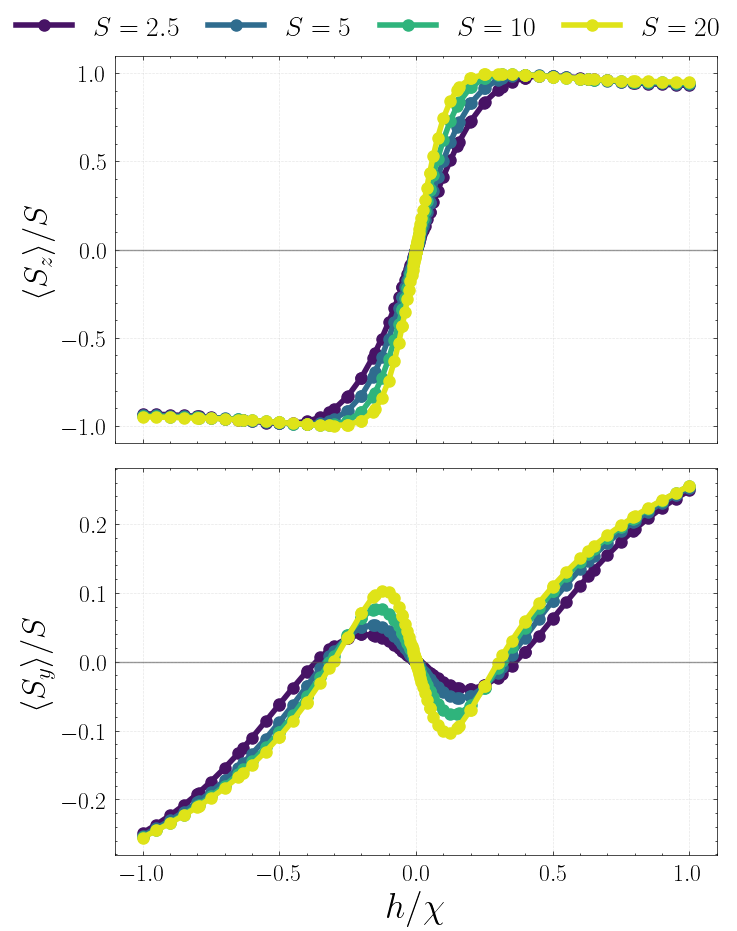

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(7.5, 10.5), sharex=True)
for ax, component in zip(axes, ("z", "y")):
    for S, color in zip([2.5, 5.0, 10.0, 20.0], plt.cm.viridis(np.linspace(0.05, 0.95, 4))):
        operator = spin_operator(S, component)
        signals = {float(h[2:]): np.vdot(state, operator @ state).real / np.vdot(state, state).real / S
                   for h, state in load_states(S, 1.0, 6).items()}
        h, signal = np.asarray(sorted(signals.items())).T
        ax.plot(h, signal, "o-", color=color, label=rf"$S={S:g}$")
    ax.axhline(0, color="0.35", linewidth=1, alpha=0.6)
    format_axis(ax, "", rf"$\langle S_{component}\rangle/S$", which="major")
axes[-1].set_xlabel(r"$h/\chi$", fontsize=26)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.917),
           ncols=4, frameon=False, fontsize=20, columnspacing=1)
fig.tight_layout(rect=(0, 0, 1, 0.88), h_pad=1)
fig.savefig("plots/mag_vs_h_vertical.pdf")
plt.show()


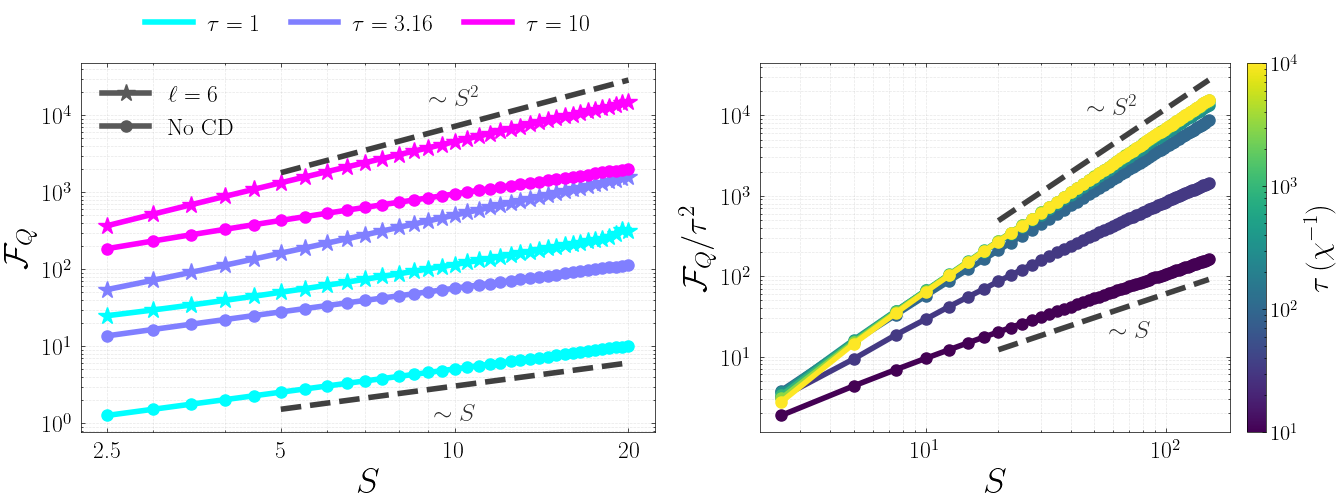

In [4]:
def qfi(S, tau, ell=0, h_step=1e-3):
    states = {float(h[2:]): state for h, state in load_states(S, tau, ell).items()}
    if h_step is None:
        hm, hp = max(h for h in states if h < 0), min(h for h in states if h > 0)
    else:
        hm, hp = [min(states, key=lambda h: abs(h - target)) for target in (-h_step, h_step)]
        if max(abs(hm + h_step), abs(hp - h_step)) > max(1e-15, h_step*1e-10):
            raise KeyError(h_step)
    minus, plus = normalize(states[hm]), normalize(states[hp])
    if ell == 0:
        return max(4*(1 - np.clip(abs(np.vdot(minus, plus))**2, 0, 1))/(hp - hm)**2, 0)
    if 0.0 in states:
        reference = normalize(states[0.0])
        for state in (minus, plus):
            state *= np.exp(-1j*np.angle(np.vdot(reference, state)))
    else:
        plus *= np.exp(-1j*np.angle(np.vdot(minus, plus)))
        reference = normalize(minus + plus)
    derivative = (plus - minus)/(hp - hm)
    return max(4*(np.vdot(derivative, derivative).real - abs(np.vdot(reference, derivative))**2), 0)

taus = np.logspace(0, 4, 41)[10::5]
cd_taus = np.logspace(0, 1, 11)[[0, 5, 10]]
norm, cd_norm = LogNorm(taus.min(), taus.max()), LogNorm(cd_taus.min(), cd_taus.max())
curves = {}
for tau in taus:
    S, values = curve(np.arange(2.5, 200.1, 2.5), lambda S: qfi(S, tau, h_step=1e-5 if np.isclose(tau, 10) else None))
    curves[tau] = (S, values/tau**2)
shared_S = np.array(sorted(set.intersection(*(set(S) for S, _ in curves.values()))))
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for tau, (S, values) in curves.items():
    values = values[np.isin(S, shared_S)]
    curves[tau] = values
    color = plt.cm.viridis(norm(tau))
    axes[1].loglog(shared_S, values, "o-", color=color)
    fit_S = shared_S[-10:]
    alpha, log_A = np.polyfit(np.log(fit_S), np.log(values[-10:]), 1)
    axes[1].loglog(fit_S, np.exp(log_A)*fit_S**alpha, "--", color=color, linewidth=2.5)

x0, x1 = max(20, shared_S.min()), shared_S.max()
mask = (shared_S >= x0) & (shared_S <= x1)
a2 = 1.75*np.max(curves[taus[-1]][mask]/shared_S[mask]**2)
a1 = 0.60*np.min(curves[taus[0]][mask]/shared_S[mask])
guide(axes[1], x0, x1, 2, r"$\sim S^2$", a2*x0**2, 0.55*x1, (-24, 18), va="top")
guide(axes[1], x0, x1, 1, r"$\sim S$", a1*x0, 0.55*x1, (-12, -30))

ratios1, ratios2 = [], []
for tau in cd_taus:
    for ell, marker, size in ((6, "*", 13), (0, "o", 8)):
        S, values = curve(np.arange(2.5, 20.01, 0.5), lambda S: qfi(S, tau, ell))
        axes[0].loglog(S, values, marker=marker, markersize=size, color=plt.cm.cool(cd_norm(tau)))
        mask = (S >= 5) & (S <= 20)
        ratios1.extend(values[mask]/S[mask])
        ratios2.extend(values[mask]/S[mask]**2)
guide(axes[0], 5, 20, 1, r"$\sim S$", 0.60*np.min(ratios1)*5, 10, (0, -12), va="top")
guide(axes[0], 5, 20, 2, r"$\sim S^2$", 1.35*np.max(ratios2)*25, 10, (0, 12))
for ax, label in zip(axes, (r"$\mathcal{F}_Q$", r"$\mathcal{F}_Q/\tau^2$")):
    format_axis(ax, r"$S$", label)
protocols = [Line2D([], [], color="0.35", marker=marker, markersize=size, label=label)
             for marker, size, label in (("*", 13, r"$\ell=6$"), ("o", 8, r"$\mathrm{No\ CD}$"))]
axes[0].add_artist(axes[0].legend(handles=protocols, frameon=False, fontsize=17, loc="best"))
handles = [Line2D([], [], color=plt.cm.cool(cd_norm(tau)), label=rf"$\tau={np.trunc(tau*100)/100:g}$") for tau in cd_taus]
axes[0].legend(handles=handles, frameon=False, fontsize=17, loc="lower center",
               bbox_to_anchor=(0.5, 1.02), ncols=3, columnspacing=1.3, handletextpad=0.6)
axes[0].set_xticks([2.5, 5, 10, 20], labels=["2.5", "5", "10", "20"])
axes[0].xaxis.set_minor_formatter(NullFormatter())
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes[1], pad=0.03)
colorbar.set_label(r"$\tau\,(\chi^{-1})$", fontsize=22)
colorbar.ax.tick_params(labelsize=15)
fig.tight_layout(w_pad=1)
fig.savefig("plots/QFI_data.pdf")
plt.show()


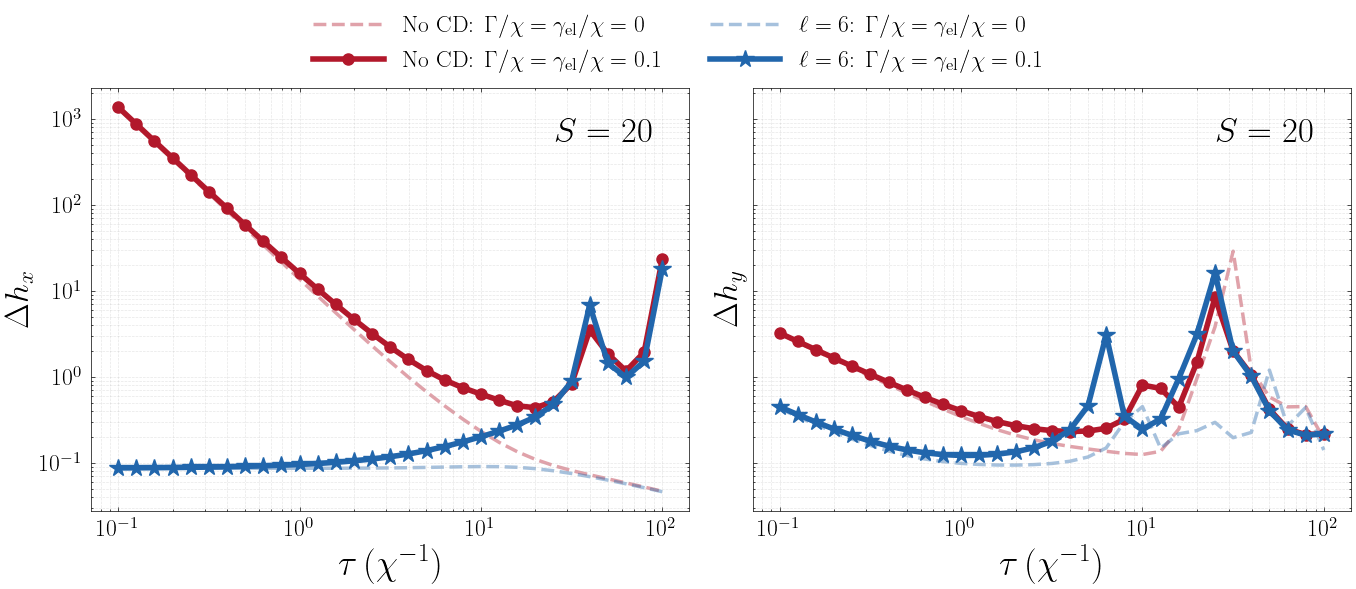

In [5]:
with h5py.File("data/uncertainty_xy_from_rho_S20.0_chi1_g1_Omega3.7000_orders0-6_rates0-0_0.1-0.1_0.5-0.5_1-1_3-3_dh0.0010_tau0.1000-100.0000_n31.h5", "r") as saved:
    taus, orders, rates, uncertainty = [saved[key][:] for key in ("tau", "orders", "rates", "qutip/delta_h")]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
for column, (ax, component) in enumerate(zip(axes, ("x", "y"))):
    for oi, (order, color) in enumerate(zip(orders, ("#B2182B", "#2166AC"))):
        label = rf"$\ell={order}$" if order else r"$\mathrm{No\ CD}$"
        for rate in (0, 0.1):
            index = np.flatnonzero(np.all(np.isclose(rates, rate), axis=1))[0]
            ax.loglog(taus, uncertainty[index, oi, :, column], color=color,
                      linestyle="-" if rate else "--", marker=("*" if order else "o") if rate else None,
                      markersize=13 if order and rate else 8, linewidth=4 if rate else 2.5,
                      alpha=1 if rate else 0.4, zorder=2 if rate else 1,
                      label=label + rf": $\Gamma/\chi=\gamma_{{\rm el}}/\chi={rate:g}$")
    ax.text(0.94, 0.93, r"$S=20$", transform=ax.transAxes, ha="right", va="top", fontsize=25)
    format_axis(ax, r"$\tau\,(\chi^{-1})$", rf"$\Delta h_{{{component}}}$")
fig.tight_layout(w_pad=1)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, axes[0].get_position().y1 + 0.01),
           borderaxespad=0, frameon=False, fontsize=17, ncols=2, handlelength=3)
fig.savefig("plots/SNR_with_noise.pdf")
plt.show()
